# Full-training artifact review: `fullTrainingCopy072726`

This notebook is a **read-only inventory and comparison** of every top-level folder in the full training export on the Desktop. It does not retrain models or select new checkpoints.

It covers:

- `cuFeffShellEncoderSweep`
- `m3gnetAll8E2EExperts`
- `m3gnetAll8E2EUniversal`
- `vaspOnlyEncoderExperts`

The tables describe the stored data, checkpoints, logs, features, predictions, and evaluation CSVs. Where a stored `eta` is available, it is compared with the OmniXAS paper reference values. Custom scratch encoders and shell-pooled representations are labeled as **exploratory** rather than treated as exact reproductions of the pinned pretrained-M3GNet paper pipeline.

## 1. Setup and paper reference values

OmniXAS predicts a 141-point nonnegative spectrum from a site-specific structural representation. The paper metric is

\[
\eta = \frac{\operatorname{median}(	ext{training-mean-spectrum MSE})}
              {\operatorname{median}(	ext{per-spectrum model MSE})}.
\]

Higher `eta` is better. Test values below are read from existing result files; this notebook does not use test values for model selection.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 48)
plt.rcParams.update({"figure.figsize": (11, 5), "axes.titlesize": 13, "axes.labelsize": 11})


def locate_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "omnixas").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the OmniXAS repository")


REPO_ROOT = locate_repo_root(Path.cwd().resolve())
DEFAULT_DATA_ROOT = REPO_ROOT.parent / "fullTrainingCopy072726"
DATA_ROOT = Path(os.environ.get("OMNIXAS_FULL_TRAINING_ROOT", DEFAULT_DATA_ROOT)).expanduser().resolve()
if not DATA_ROOT.is_dir():
    raise FileNotFoundError(
        f"Training export not found: {DATA_ROOT}. Set OMNIXAS_FULL_TRAINING_ROOT to the folder containing the four runs."
    )

FOLDER_NAMES = [
    "cuFeffShellEncoderSweep",
    "m3gnetAll8E2EExperts",
    "m3gnetAll8E2EUniversal",
    "vaspOnlyEncoderExperts",
]
missing_folders = [name for name in FOLDER_NAMES if not (DATA_ROOT / name).is_dir()]
if missing_folders:
    raise FileNotFoundError(f"Missing expected top-level folders under {DATA_ROOT}: {missing_folders}")

FEFF_ELEMENTS = ["Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu"]
DATASET_ORDER = [f"{element}_FEFF" for element in FEFF_ELEMENTS] + ["Ti_VASP", "Cu_VASP"]

# Reference values used in the existing OmniXAS paper-style notebooks.
PAPER_EXPERT_TEST_ETA = {
    "Ti_FEFF": 6.35, "V_FEFF": 7.30, "Cr_FEFF": 8.54, "Mn_FEFF": 17.66,
    "Fe_FEFF": 7.51, "Co_FEFF": 14.47, "Ni_FEFF": 8.45, "Cu_FEFF": 5.19,
    "Ti_VASP": 4.75, "Cu_VASP": 8.46,
}
PAPER_UNIVERSAL_TEST_ETA = {
    "Ti_FEFF": 4.19, "V_FEFF": 5.19, "Cr_FEFF": 7.13, "Mn_FEFF": 13.15,
    "Fe_FEFF": 6.04, "Co_FEFF": 9.58, "Ni_FEFF": 6.43, "Cu_FEFF": 2.75,
}
PAPER_TUNED_TEST_ETA = {
    "Ti_FEFF": 7.63, "V_FEFF": 9.22, "Cr_FEFF": 10.44, "Mn_FEFF": 29.81,
    "Fe_FEFF": 8.98, "Co_FEFF": 19.83, "Ni_FEFF": 11.21, "Cu_FEFF": 4.81,
    "Ti_VASP": 5.27, "Cu_VASP": 9.21,
}

# Published row counts: 75,691 site-specific spectra in total.
PAPER_COUNTS = {
    "Ti_FEFF": 6422, "V_FEFF": 10813, "Cr_FEFF": 3067, "Mn_FEFF": 17052,
    "Fe_FEFF": 12067, "Co_FEFF": 10753, "Ni_FEFF": 4335, "Cu_FEFF": 4172,
    "Ti_VASP": 3784, "Cu_VASP": 3226,
}
PAPER_TOTAL = sum(PAPER_COUNTS.values())

print(f"Repository: {REPO_ROOT}")
print(f"Training export: {DATA_ROOT}")
print(f"Published-scope row count used for checks: {PAPER_TOTAL:,}")

Repository: /mnt/c/Users/anton/desktop/omnixas
Training export: /mnt/c/Users/anton/desktop/fullTrainingCopy072726
Published-scope row count used for checks: 75,691


## 2. Folder-level inventory

The first table counts all files recursively. Checkpoint sizes are included because these exports contain many large binary artifacts; the notebook summarizes them without opening model weights.

In [2]:
def human_bytes(value: int) -> str:
    value = float(value)
    for unit in ["B", "KiB", "MiB", "GiB"]:
        if value < 1024 or unit == "GiB":
            return f"{value:.1f} {unit}"
        value /= 1024
    return f"{value:.1f} GiB"


def classify_file(path: Path) -> str:
    name = path.name.lower()
    if name == "done":
        return "DONE marker"
    if name.startswith("events.out.tfevents."):
        return "TensorBoard event"
    if path.suffix.lower() == ".ckpt":
        return "checkpoint"
    if path.suffix.lower() == ".npz":
        return "NPZ archive"
    if path.suffix.lower() == ".txt":
        return "text array"
    if path.suffix.lower() == ".csv":
        return "CSV"
    if path.suffix.lower() == ".json":
        return "JSON"
    if path.suffix.lower() == ".yaml":
        return "YAML"
    if path.suffix.lower() == ".png":
        return "plot"
    return "other"


def inventory_table(root: Path) -> pd.DataFrame:
    rows = []
    kinds = [
        "checkpoint", "NPZ archive", "text array", "CSV", "JSON", "YAML",
        "plot", "TensorBoard event", "DONE marker", "other",
    ]
    for folder in sorted(p for p in root.iterdir() if p.is_dir()):
        files = [p for p in folder.rglob("*") if p.is_file()]
        counts = pd.Series([classify_file(p) for p in files]).value_counts().to_dict()
        row = {
            "folder": folder.name,
            "run_dirs": sum(p.is_dir() for p in folder.iterdir()),
            "files": len(files),
            "total_size": human_bytes(sum(p.stat().st_size for p in files)),
            "total_size_GiB": sum(p.stat().st_size for p in files) / 1024**3,
        }
        row.update({kind: int(counts.get(kind, 0)) for kind in kinds})
        rows.append(row)
    return pd.DataFrame(rows)


inventory = inventory_table(DATA_ROOT)
display(
    inventory[
        ["folder", "run_dirs", "files", "total_size", "total_size_GiB", "checkpoint", "NPZ archive", "text array", "CSV", "JSON", "YAML", "plot", "TensorBoard event"]
    ].style.format({"total_size_GiB": "{:.3f}"})
)

,folder,run_dirs,files,total_size,total_size_GiB,checkpoint,NPZ archive,text array,CSV,JSON,YAML,plot,TensorBoard event
0,cuFeffShellEncoderSweep,3,319,824.3 MiB,0.805,88,44,0,13,4,40,6,120
1,m3gnetAll8E2EExperts,1,4,127.2 MiB,0.124,2,0,0,1,1,0,0,0
2,m3gnetAll8E2EUniversal,1,254,903.8 MiB,0.883,65,0,60,4,1,31,0,93
3,vaspOnlyEncoderExperts,1,23,65.9 MiB,0.064,5,0,12,1,1,1,0,3


## 3. Data contract and split coverage

The exported feature/target text files should preserve the paper ordering and split membership. The checks below inspect line counts and column counts without loading the full arrays into memory.

Expected contract:

- features: 64 columns for the custom encoder exports;
- targets: 141 columns;
- each `X` and `y` split has identical row counts;
- train/validation/test totals match the published 75,691-row scope.

In [3]:
def text_shape(path: Path) -> tuple[int, int]:
    row_count = 0
    width = None
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            if not line.strip():
                continue
            row_count += 1
            if width is None:
                width = len(line.split())
    return row_count, int(width or 0)


def split_shape_table(features_dir: Path, datasets: list[str], source: str) -> pd.DataFrame:
    rows = []
    for dataset in datasets:
        for split in ["train", "val", "test"]:
            x_path = features_dir / f"{dataset}_{split}_X.txt"
            y_path = features_dir / f"{dataset}_{split}_y.txt"
            if not x_path.is_file() or not y_path.is_file():
                raise FileNotFoundError(f"Missing paired split files for {dataset} {split}: {x_path}, {y_path}")
            x_rows, x_dim = text_shape(x_path)
            y_rows, y_dim = text_shape(y_path)
            rows.append({
                "source": source,
                "dataset": dataset,
                "split": split,
                "X_rows": x_rows,
                "y_rows": y_rows,
                "X_dim": x_dim,
                "y_dim": y_dim,
                "rows_match": x_rows == y_rows,
            })
    return pd.DataFrame(rows)


UNIVERSAL_RUN = DATA_ROOT / "m3gnetAll8E2EUniversal" / "e2e_universal_seed42"
VASP_RUN = DATA_ROOT / "vaspOnlyEncoderExperts" / "vasp_encoder_seed42"
universal_shapes = split_shape_table(UNIVERSAL_RUN / "features", DATASET_ORDER, "E2E universal export")
vasp_shapes = split_shape_table(VASP_RUN / "features", ["Ti_VASP", "Cu_VASP"], "VASP-only encoder export")

shape_checks = pd.concat([universal_shapes, vasp_shapes], ignore_index=True)
if not shape_checks["rows_match"].all() or not (shape_checks["X_dim"] == 64).all() or not (shape_checks["y_dim"] == 141).all():
    raise ValueError("Feature/target shape contract failed")

coverage = (
    shape_checks.groupby(["source", "dataset"], sort=False)
    .agg(
        train_rows=("X_rows", lambda s: int(s.iloc[0])),
        val_rows=("X_rows", lambda s: int(s.iloc[1])),
        test_rows=("X_rows", lambda s: int(s.iloc[2])),
        feature_dim=("X_dim", "first"),
        target_dim=("y_dim", "first"),
    )
    .reset_index()
)
coverage["total_rows"] = coverage[["train_rows", "val_rows", "test_rows"]].sum(axis=1)
coverage["paper_rows"] = coverage["dataset"].map(PAPER_COUNTS)
coverage["matches_paper_scope"] = coverage["total_rows"] == coverage["paper_rows"]
display(coverage.style.format({"train_rows": "{:,}", "val_rows": "{:,}", "test_rows": "{:,}", "total_rows": "{:,}", "paper_rows": "{:,}"}))

print(f"E2E universal export rows: {coverage.loc[coverage.source.eq('E2E universal export'), 'total_rows'].sum():,}")
print(f"VASP-only export rows: {coverage.loc[coverage.source.eq('VASP-only encoder export'), 'total_rows'].sum():,}")

,source,dataset,train_rows,val_rows,test_rows,feature_dim,target_dim,total_rows,paper_rows,matches_paper_scope
0,E2E universal export,Ti_FEFF,"5,140",641,641,64,141,"6,422","6,422",True
1,E2E universal export,V_FEFF,"8,653","1,080","1,080",64,141,"10,813","10,813",True
2,E2E universal export,Cr_FEFF,"2,457",305,305,64,141,"3,067","3,067",True
3,E2E universal export,Mn_FEFF,"13,644","1,704","1,704",64,141,"17,052","17,052",True
4,E2E universal export,Fe_FEFF,"9,657","1,205","1,205",64,141,"12,067","12,067",True
5,E2E universal export,Co_FEFF,"8,605","1,074","1,074",64,141,"10,753","10,753",True
6,E2E universal export,Ni_FEFF,"3,471",432,432,64,141,"4,335","4,335",True
7,E2E universal export,Cu_FEFF,"3,340",416,416,64,141,"4,172","4,172",True
8,E2E universal export,Ti_VASP,"3,030",377,377,64,141,"3,784","3,784",True
9,E2E universal export,Cu_VASP,"2,584",321,321,64,141,"3,226","3,226",True


E2E universal export rows: 75,691
VASP-only export rows: 7,010


In [4]:
paper_reference = pd.DataFrame({
    "dataset": DATASET_ORDER,
    "paper_ExpertXAS_test_eta": [PAPER_EXPERT_TEST_ETA[d] for d in DATASET_ORDER],
    "paper_UniversalXAS_test_eta": [PAPER_UNIVERSAL_TEST_ETA.get(d, np.nan) for d in DATASET_ORDER],
    "paper_Tuned_UniversalXAS_test_eta": [PAPER_TUNED_TEST_ETA[d] for d in DATASET_ORDER],
    "paper_rows": [PAPER_COUNTS[d] for d in DATASET_ORDER],
})
display(paper_reference.style.format({
    "paper_ExpertXAS_test_eta": "{:.2f}",
    "paper_UniversalXAS_test_eta": "{:.2f}",
    "paper_Tuned_UniversalXAS_test_eta": "{:.2f}",
    "paper_rows": "{:,}",
}))

,dataset,paper_ExpertXAS_test_eta,paper_UniversalXAS_test_eta,paper_Tuned_UniversalXAS_test_eta,paper_rows
0,Ti_FEFF,6.35,4.19,7.63,"6,422"
1,V_FEFF,7.30,5.19,9.22,"10,813"
2,Cr_FEFF,8.54,7.13,10.44,"3,067"
3,Mn_FEFF,17.66,13.15,29.81,"17,052"
4,Fe_FEFF,7.51,6.04,8.98,"12,067"
5,Co_FEFF,14.47,9.58,19.83,"10,753"
6,Ni_FEFF,8.45,6.43,11.21,"4,335"
7,Cu_FEFF,5.19,2.75,4.81,"4,172"
8,Ti_VASP,4.75,nan,5.27,"3,784"
9,Cu_VASP,8.46,nan,9.21,"3,226"


## 4. `cuFeffShellEncoderSweep`

This folder contains three Cu FEFF experiments:

- `run_001`: one learned 128-wide encoder, producing a 384D weighted-shell representation;
- `run_002`: one learned 64-wide encoder, producing a 192D weighted-shell representation;
- `run_003_two_encoders`: two independent 64-wide encoders (seeds 43 and 44), each with ten ExpertXAS heads.

All use the Cu FEFF split (`3340 / 416 / 416`) and 141-point targets. These are learned Cu-specific shell features, not the paper's frozen `M3GNet-MP-2021.2.8-PES` 64D absorbing-site state. Therefore the eta comparison is useful for scale and direction, but is not a strict paper reproduction.

In [5]:
SHELL_ROOT = DATA_ROOT / "cuFeffShellEncoderSweep"


def npz_shapes(path: Path) -> dict[str, tuple[int, ...]]:
    with np.load(path, allow_pickle=False) as archive:
        return {key: tuple(archive[key].shape) for key in archive.files}


shell_config_rows = []
for run_dir in sorted(p for p in SHELL_ROOT.iterdir() if p.is_dir()):
    encoder_dirs = sorted(run_dir.glob("learned_*"))
    for encoder_dir in encoder_dirs:
        config = json.loads((encoder_dir / "config.json").read_text(encoding="utf-8"))
        feature_archive = encoder_dir / "features.npz"
        shapes = npz_shapes(feature_archive)
        feature_key = next(key for key in shapes if key.startswith("site_shells_3_5_weighted_train"))
        feature_dim = shapes[feature_key][1]
        head_root = encoder_dir / "site_shells_3_5_weighted" / "heads"
        head_dirs = sorted(p for p in head_root.iterdir() if p.is_dir())
        best_head_count = sum(len(list(p.glob("best*.ckpt"))) for p in head_dirs)
        prediction_count = len(list(head_root.rglob("predictions.npz")))
        encoder_checkpoint_count = len(list((encoder_dir / "encoder_checkpoints").glob("*.ckpt")))
        shell_config_rows.append({
            "run": run_dir.name,
            "encoder": encoder_dir.name,
            "seed": config["seed"],
            "width": config["encoder_width"],
            "shell_feature_dim": feature_dim,
            "train_rows": shapes["ids_train"][0],
            "val_rows": shapes["ids_val"][0],
            "test_rows": shapes["ids_test"][0],
            "head_runs": len(head_dirs),
            "best_head_checkpoints": best_head_count,
            "prediction_archives": prediction_count,
            "encoder_checkpoints": encoder_checkpoint_count,
            "feature_scale": config["feature_scale"],
        })

shell_configs = pd.DataFrame(shell_config_rows)
display(shell_configs)

assert sorted(shell_configs["shell_feature_dim"].unique()) == [192, 384]
assert shell_configs[["train_rows", "val_rows", "test_rows"]].eq([3340, 416, 416]).all(axis=1).all()

,run,encoder,seed,width,shell_feature_dim,train_rows,val_rows,test_rows,head_runs,best_head_checkpoints,prediction_archives,encoder_checkpoints,feature_scale
0,run_001,learned_128d_seed42,42,128,384,3340,416,416,10,10,10,2,1000.0
1,run_002,learned_64d_seed42,42,64,192,3340,416,416,10,10,10,2,1000.0
2,run_003_two_encoders,learned_64d_seed43,43,64,192,3340,416,416,10,10,10,2,1000.0
3,run_003_two_encoders,learned_64d_seed44,44,64,192,3340,416,416,10,10,10,2,1000.0


In [6]:
# Normalize the three summary.csv formats into one table.
sweep_rows = []
for summary_path in sorted(SHELL_ROOT.glob("run*/summary.csv")):
    frame = pd.read_csv(summary_path)
    run_name = summary_path.parent.name
    combo_column = "feature" if "feature" in frame.columns else "combo"
    val_column = "ensemble_val_eta" if "ensemble_val_eta" in frame.columns else "val_eta"
    test_column = "ensemble_test_eta" if "ensemble_test_eta" in frame.columns else "test_eta"
    for _, row in frame.iterrows():
        sweep_rows.append({
            "run": run_name,
            "combo": row[combo_column],
            "kind": row.get("kind", "stored summary"),
            "n_members": row["n_members"],
            "val_eta": pd.to_numeric(row[val_column], errors="coerce"),
            "test_eta": pd.to_numeric(row[test_column], errors="coerce"),
        })

sweep_scores = pd.DataFrame(sweep_rows)
display(sweep_scores.style.format({"val_eta": "{:.3f}", "test_eta": "{:.3f}"}, na_rep="—"))

observed_shell = sweep_scores[
    sweep_scores["test_eta"].notna()
    & ~sweep_scores["combo"].str.contains("paper|old v1", case=False, na=False)
].copy()
observed_shell["paper_ExpertXAS_test_eta"] = PAPER_EXPERT_TEST_ETA["Cu_FEFF"]
observed_shell["paper_UniversalXAS_test_eta"] = PAPER_UNIVERSAL_TEST_ETA["Cu_FEFF"]
observed_shell["paper_Tuned_UniversalXAS_test_eta"] = PAPER_TUNED_TEST_ETA["Cu_FEFF"]
observed_shell["delta_vs_paper_ExpertXAS"] = observed_shell["test_eta"] - observed_shell["paper_ExpertXAS_test_eta"]
display(observed_shell[["run", "combo", "n_members", "val_eta", "test_eta", "paper_ExpertXAS_test_eta", "paper_UniversalXAS_test_eta", "paper_Tuned_UniversalXAS_test_eta", "delta_vs_paper_ExpertXAS"]].style.format("{:.3f}", subset=pd.IndexSlice[:, ["val_eta", "test_eta", "paper_ExpertXAS_test_eta", "paper_UniversalXAS_test_eta", "paper_Tuned_UniversalXAS_test_eta", "delta_vs_paper_ExpertXAS"]]))

,run,combo,kind,n_members,val_eta,test_eta
0,run_001,paper ExpertXAS,reference,1,—,5.190
1,run_001,old v1 20-member ensemble,reference,20,7.480,7.640
2,run_001,learned_site_shells_3_5_weighted_128d,learned_encoder,10,6.956,6.769
3,run_002,paper ExpertXAS,reference,1,—,5.190
4,run_002,old v1 20-member ensemble,reference,20,7.480,7.640
5,run_002,learned_site_shells_3_5_weighted_64d,learned_encoder,10,7.261,7.000
6,run_003_two_encoders,paper ExpertXAS,stored summary,1,—,5.190
7,run_003_two_encoders,old v1 20-member ensemble,stored summary,20,7.480,7.640
8,run_003_two_encoders,all_20_heads,stored summary,20,7.469,8.085
9,run_003_two_encoders,encoder_seed43_10_head_ensemble,stored summary,10,7.234,7.625


,run,combo,n_members,val_eta,test_eta,paper_ExpertXAS_test_eta,paper_UniversalXAS_test_eta,paper_Tuned_UniversalXAS_test_eta,delta_vs_paper_ExpertXAS
2,run_001,learned_site_shells_3_5_weighted_128d,10,6.956,6.769,5.190,2.750,4.810,1.579
5,run_002,learned_site_shells_3_5_weighted_64d,10,7.261,7.000,5.190,2.750,4.810,1.810
8,run_003_two_encoders,all_20_heads,20,7.469,8.085,5.190,2.750,4.810,2.895
9,run_003_two_encoders,encoder_seed43_10_head_ensemble,10,7.234,7.625,5.190,2.750,4.810,2.435
10,run_003_two_encoders,best_validation_head,1,7.209,7.196,5.190,2.750,4.810,2.006
11,run_003_two_encoders,encoder_seed44_10_head_ensemble,10,6.804,7.049,5.190,2.750,4.810,1.859


In [7]:
member_frames = []
for members_path in sorted(SHELL_ROOT.glob("run*/members.csv")):
    frame = pd.read_csv(members_path)
    frame["run"] = members_path.parent.name
    if "encoder_seed" not in frame.columns:
        frame["encoder_seed"] = frame["run"].map({"run_001": 42, "run_002": 42})
    member_frames.append(frame)

members = pd.concat(member_frames, ignore_index=True)
member_stability = (
    members.groupby(["run", "encoder_seed"], dropna=False)
    .agg(
        n_heads=("test_eta", "size"),
        val_eta_mean=("val_eta", "mean"),
        val_eta_std=("val_eta", "std"),
        test_eta_mean=("test_eta", "mean"),
        test_eta_std=("test_eta", "std"),
        best_val_eta=("val_eta", "max"),
        test_eta_at_best_val=("test_eta", lambda s: float(s.loc[members.loc[s.index, "val_eta"].idxmax()])),
    )
    .reset_index()
)
display(member_stability.style.format({column: "{:.3f}" for column in member_stability.columns if "eta" in column}))

,run,encoder_seed,n_heads,val_eta_mean,val_eta_std,test_eta_mean,test_eta_std,best_val_eta,test_eta_at_best_val
0,run_001,42,10,6.830,0.084,6.662,0.155,6.934,6.951
1,run_002,42,10,7.003,0.134,6.519,0.178,7.181,6.312
2,run_003_two_encoders,43,10,7.053,0.108,7.082,0.203,7.209,7.196
3,run_003_two_encoders,44,10,6.562,0.087,6.610,0.159,6.746,6.630


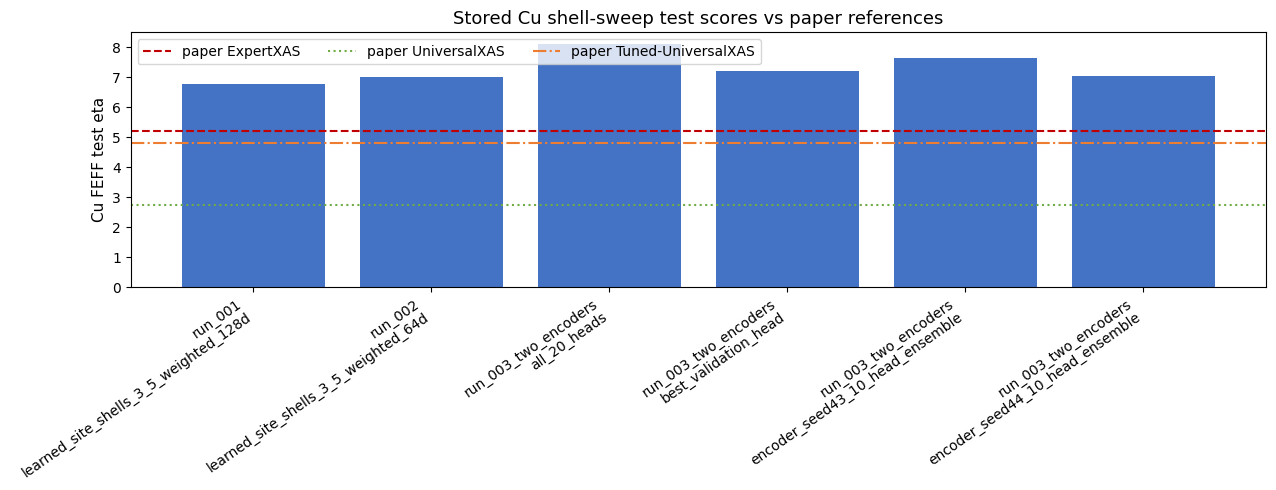

In [8]:
plot_scores = observed_shell.sort_values(["run", "combo"]).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(np.arange(len(plot_scores)), plot_scores["test_eta"], color="#4472C4")
ax.axhline(PAPER_EXPERT_TEST_ETA["Cu_FEFF"], color="#C00000", linestyle="--", label="paper ExpertXAS")
ax.axhline(PAPER_UNIVERSAL_TEST_ETA["Cu_FEFF"], color="#70AD47", linestyle=":", label="paper UniversalXAS")
ax.axhline(PAPER_TUNED_TEST_ETA["Cu_FEFF"], color="#ED7D31", linestyle="-.", label="paper Tuned-UniversalXAS")
ax.set_xticks(np.arange(len(plot_scores)))
ax.set_xticklabels([f"{r.run}\n{r.combo}" for r in plot_scores.itertuples()], rotation=35, ha="right")
ax.set_ylabel("Cu FEFF test eta")
ax.set_title("Stored Cu shell-sweep test scores vs paper references")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

**Interpretation.** The shell experiments improve over the paper ExpertXAS reference in the stored Cu test comparisons only if the higher eta is interpreted at face value, but they use a different learned representation and head ensemble protocol. The run-003 `all_20_heads` test score is lower than its validation score, which is a reminder to keep validation-based selection separate from test reporting.

## 5. `m3gnetAll8E2EExperts`

This is an end-to-end custom scratch-encoder run with task-specific FEFF ExpertXAS heads routed by element. The stored folder contains the joint checkpoint and its training log, but it stops before the later feature-export and continued-head evaluation stages described by `train_e2e_custom_experts.py`.

Consequently, no test eta is invented here. The missing artifacts are reported explicitly.

In [9]:
EXPERTS_RUN = DATA_ROOT / "m3gnetAll8E2EExperts" / "e2e_expert_seed42"
expert_settings = json.loads((EXPERTS_RUN / "run_settings.json").read_text(encoding="utf-8"))["args"]
expert_metrics = pd.read_csv(EXPERTS_RUN / "e2e_logs" / "version_0" / "metrics.csv")


def checkpoint_inventory(root: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(root.rglob("*.ckpt")):
        rows.append({
            "relative_path": str(path.relative_to(root)),
            "role": "best" if "best" in path.name.lower() else "last/other",
            "size_MiB": path.stat().st_size / 1024**2,
        })
    return pd.DataFrame(rows)


expert_checkpoints = checkpoint_inventory(EXPERTS_RUN)
display(expert_checkpoints.style.format({"size_MiB": "{:.2f}"}))

validation_rows = expert_metrics.copy()
for column in ["epoch", "val_balanced_rel_mse", "val_loss", "val_mse"]:
    validation_rows[column] = pd.to_numeric(validation_rows[column], errors="coerce")
validation_rows = validation_rows.dropna(subset=["val_balanced_rel_mse"])
if validation_rows.empty:
    raise ValueError("The E2E expert log has no validation rows")
best_expert_row = validation_rows.loc[validation_rows["val_balanced_rel_mse"].idxmin()]

expert_summary = pd.DataFrame([{
    "seed": expert_settings["seed"],
    "gnn_dropout": expert_settings["gnn_dropout"],
    "head_dropout": expert_settings["head_dropout"],
    "configured_e2e_epochs": expert_settings["e2e_epochs"],
    "validation_epochs_logged": int(validation_rows["epoch"].nunique()),
    "best_epoch": int(best_expert_row["epoch"]),
    "best_val_balanced_rel_mse": best_expert_row["val_balanced_rel_mse"],
    "best_val_loss": best_expert_row["val_loss"],
    "best_val_mse": best_expert_row["val_mse"],
    "test_eta_stored": False,
}])
display(expert_summary.style.format({
    "best_val_balanced_rel_mse": "{:.4f}", "best_val_loss": "{:.4f}", "best_val_mse": "{:.4f}"
}))

expected_expert_outputs = [
    "best_e2e_encoder_experts.ckpt",
    "features",
    "heads/expertXAS",
    "continued_expert_eval.csv",
]
stage_check = pd.DataFrame([
    {"expected_output": relative, "present": (EXPERTS_RUN / relative).exists()}
    for relative in expected_expert_outputs
])
display(stage_check)

,relative_path,role,size_MiB
0,checkpoints/best-epoch=171-val_balanced_rel_mse=0.10036.ckpt,best,51.26
1,checkpoints/last.ckpt,last/other,51.26


,seed,gnn_dropout,head_dropout,configured_e2e_epochs,validation_epochs_logged,best_epoch,best_val_balanced_rel_mse,best_val_loss,best_val_mse,test_eta_stored
0,42,0.100000,0.500000,300,174,171,0.1004,0.1978,0.0059,False


,expected_output,present
0,best_e2e_encoder_experts.ckpt,False
1,features,False
2,heads/expertXAS,False
3,continued_expert_eval.csv,False


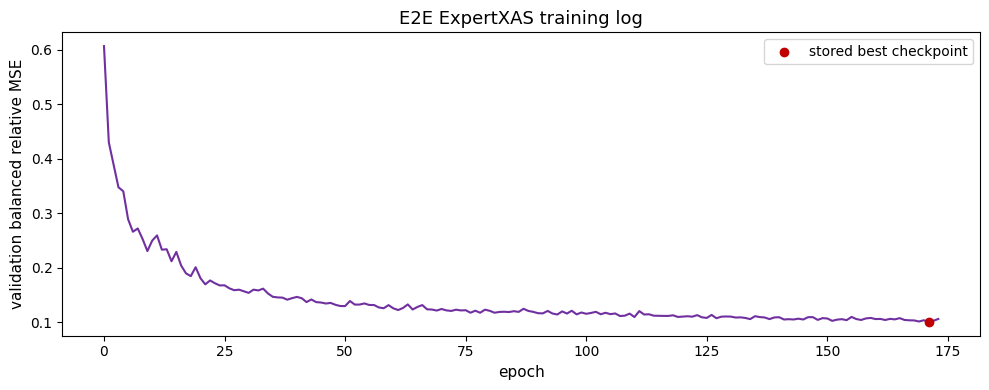

In [10]:
expert_curve = validation_rows.groupby("epoch", as_index=False)["val_balanced_rel_mse"].min()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(expert_curve["epoch"], expert_curve["val_balanced_rel_mse"], color="#7030A0")
ax.scatter([best_expert_row["epoch"]], [best_expert_row["val_balanced_rel_mse"],], color="#C00000", zorder=3, label="stored best checkpoint")
ax.set_xlabel("epoch")
ax.set_ylabel("validation balanced relative MSE")
ax.set_title("E2E ExpertXAS training log")
ax.legend()
plt.tight_layout()
plt.show()

**Paper comparison.** The paper reports test eta for eight FEFF ExpertXAS models, while this folder stores a joint end-to-end training objective and no per-dataset test evaluation. Its `val_balanced_rel_mse` is not the paper's per-dataset test eta, so the two numbers should not be substituted for one another.

## 6. `m3gnetAll8E2EUniversal`

This is the most complete export. It contains:

1. a custom scratch encoder trained end-to-end with one UniversalXAS head;
2. 64D exported features for all eight FEFF datasets and the two VASP datasets;
3. continued UniversalXAS and validation-selected tuned-head checkpoints;
4. `universal_eval.csv`, `tuned_validation_candidates.csv`, and `tuned_eval.csv`.

The feature and target arrays preserve the 64D / 141D contract and all 75,691 rows. The encoder is custom and scratch-trained, so its scores are exploratory relative to the paper's pinned pretrained M3GNet representation.

In [11]:
universal_settings = json.loads((UNIVERSAL_RUN / "run_settings.json").read_text(encoding="utf-8"))["args"]
settings_view = pd.DataFrame([{
    "seed": universal_settings["seed"],
    "gnn_dropout": universal_settings["gnn_dropout"],
    "e2e_epochs": universal_settings["e2e_epochs"],
    "e2e_encoder_lr": universal_settings["e2e_encoder_lr"],
    "e2e_head_lr": universal_settings["e2e_head_lr"],
    "e2e_head_dropout": universal_settings["e2e_head_dropout"],
    "universal_epochs": universal_settings["universal_epochs"],
    "universal_dropout": universal_settings["universal_dropout"],
    "tuned_epochs": universal_settings["tuned_epochs"],
    "tuned_patience": universal_settings["tuned_patience"],
}])
display(settings_view)

universal_artifact_counts = pd.DataFrame([{
    "best_or_last_checkpoints": len(list(UNIVERSAL_RUN.rglob("*.ckpt"))),
    "feature_text_files": len(list((UNIVERSAL_RUN / "features").glob("*.txt"))),
    "universal_eval_rows": len(pd.read_csv(UNIVERSAL_RUN / "universal_eval.csv")),
    "tuned_candidate_rows": len(pd.read_csv(UNIVERSAL_RUN / "tuned_validation_candidates.csv")),
    "tuned_eval_rows": len(pd.read_csv(UNIVERSAL_RUN / "tuned_eval.csv")),
}])
display(universal_artifact_counts)

,seed,gnn_dropout,e2e_epochs,e2e_encoder_lr,e2e_head_lr,e2e_head_dropout,universal_epochs,universal_dropout,tuned_epochs,tuned_patience
0,42,0.1,300,0.001,0.0007,0.25,800,0.25,1000,25


,best_or_last_checkpoints,feature_text_files,universal_eval_rows,tuned_candidate_rows,tuned_eval_rows
0,65,60,10,30,10


In [12]:
universal_eval = pd.read_csv(UNIVERSAL_RUN / "universal_eval.csv")
tuned_eval = pd.read_csv(UNIVERSAL_RUN / "tuned_eval.csv")

universal_eval_view = universal_eval[["dataset", "val_eta", "test_eta", "test_median_mse"]].rename(columns={
    "val_eta": "custom_universal_val_eta",
    "test_eta": "custom_universal_test_eta",
    "test_median_mse": "custom_universal_test_median_mse",
})
tuned_eval_view = tuned_eval[["dataset", "val_eta", "test_eta", "test_median_mse"]].rename(columns={
    "val_eta": "custom_tuned_val_eta",
    "test_eta": "custom_tuned_test_eta",
    "test_median_mse": "custom_tuned_test_median_mse",
})

universal_comparison = pd.merge(universal_eval_view, tuned_eval_view, on="dataset", how="outer", validate="one_to_one")
universal_comparison["paper_ExpertXAS_test_eta"] = universal_comparison["dataset"].map(PAPER_EXPERT_TEST_ETA)
universal_comparison["paper_UniversalXAS_test_eta"] = universal_comparison["dataset"].map(PAPER_UNIVERSAL_TEST_ETA)
universal_comparison["paper_Tuned_UniversalXAS_test_eta"] = universal_comparison["dataset"].map(PAPER_TUNED_TEST_ETA)
universal_comparison["custom_tuned_minus_custom_universal"] = universal_comparison["custom_tuned_test_eta"] - universal_comparison["custom_universal_test_eta"]
universal_comparison = universal_comparison.set_index("dataset").reindex(DATASET_ORDER).reset_index()

universal_display_columns = [
    "dataset", "custom_universal_val_eta", "custom_universal_test_eta", "custom_tuned_val_eta", "custom_tuned_test_eta",
    "paper_ExpertXAS_test_eta", "paper_UniversalXAS_test_eta", "paper_Tuned_UniversalXAS_test_eta",
    "custom_tuned_minus_custom_universal",
]
universal_numeric_columns = [column for column in universal_display_columns if column != "dataset"]
display(
    universal_comparison[universal_display_columns]
    .style.format({column: "{:.3f}" for column in universal_numeric_columns}, na_rep="—")
)

,dataset,custom_universal_val_eta,custom_universal_test_eta,custom_tuned_val_eta,custom_tuned_test_eta,paper_ExpertXAS_test_eta,paper_UniversalXAS_test_eta,paper_Tuned_UniversalXAS_test_eta,custom_tuned_minus_custom_universal
0,Ti_FEFF,9.461,10.214,10.692,10.606,6.350,4.190,7.630,0.393
1,V_FEFF,12.064,10.448,12.758,11.144,7.300,5.190,9.220,0.696
2,Cr_FEFF,13.280,15.018,15.522,17.372,8.540,7.130,10.440,2.354
3,Mn_FEFF,24.332,23.228,33.030,30.562,17.660,13.150,29.810,7.334
4,Fe_FEFF,13.488,13.570,14.685,14.288,7.510,6.040,8.980,0.718
5,Co_FEFF,24.569,22.568,27.706,25.102,14.470,9.580,19.830,2.534
6,Ni_FEFF,16.108,15.045,16.510,15.278,8.450,6.430,11.210,0.233
7,Cu_FEFF,6.091,6.141,7.092,6.751,5.190,2.750,4.810,0.610
8,Ti_VASP,0.936,1.032,5.135,5.220,4.750,—,5.270,4.187
9,Cu_VASP,1.308,1.393,7.050,7.346,8.460,—,9.210,5.952


,dataset,setting,selected_val_eta,selected_test_eta
0,Ti_FEFF,cosT500_lr3e-4_do0p1,10.692,10.606
1,V_FEFF,cosT250_lr1e-4_do0p0,12.758,11.144
2,Cr_FEFF,cosT500_lr3e-4_do0p1,15.522,17.372
3,Mn_FEFF,cosT500_lr3e-4_do0p1,33.030,30.562
4,Fe_FEFF,cosT500_lr3e-4_do0p1,14.685,14.288
5,Co_FEFF,cosT500_lr3e-4_do0p1,27.706,25.102
6,Ni_FEFF,cosT500_lr3e-4_do0p1,16.510,15.278
7,Cu_FEFF,cosT500_lr3e-4_do0p1,7.092,6.751
8,Ti_VASP,cosT600_lr5e-4_do0p25,5.135,5.220
9,Cu_VASP,cosT600_lr5e-4_do0p25,7.050,7.346


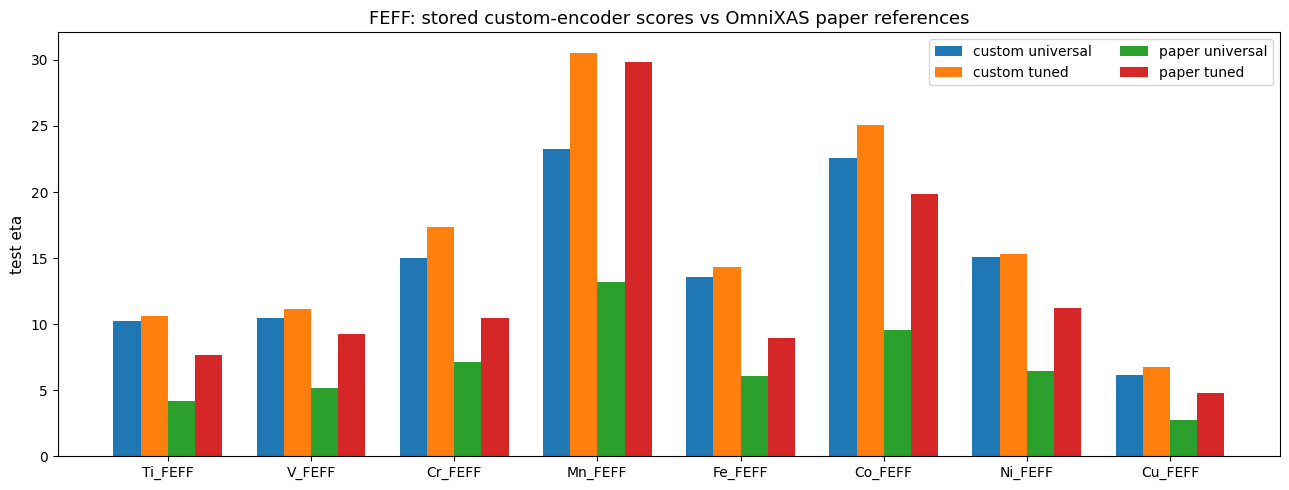

In [13]:
# The tuned validation sweep is visible, but the test table above contains only the validation-selected rows.
tuned_candidates = pd.read_csv(UNIVERSAL_RUN / "tuned_validation_candidates.csv")
candidate_counts = tuned_candidates.groupby(["dataset", "setting"], as_index=False).size()
selected_settings = tuned_eval[["dataset", "setting", "val_eta", "test_eta"]].copy()
selected_settings = selected_settings.rename(columns={"val_eta": "selected_val_eta", "test_eta": "selected_test_eta"})
display(selected_settings.set_index("dataset").reindex(DATASET_ORDER).reset_index().style.format({"selected_val_eta": "{:.3f}", "selected_test_eta": "{:.3f}"}))

feff_comparison = universal_comparison[universal_comparison["dataset"].str.endswith("_FEFF")].copy()
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(feff_comparison))
width = 0.19
ax.bar(x - 1.5 * width, feff_comparison["custom_universal_test_eta"], width, label="custom universal")
ax.bar(x - 0.5 * width, feff_comparison["custom_tuned_test_eta"], width, label="custom tuned")
ax.bar(x + 0.5 * width, feff_comparison["paper_UniversalXAS_test_eta"], width, label="paper universal")
ax.bar(x + 1.5 * width, feff_comparison["paper_Tuned_UniversalXAS_test_eta"], width, label="paper tuned")
ax.set_xticks(x, feff_comparison["dataset"])
ax.set_ylabel("test eta")
ax.set_title("FEFF: stored custom-encoder scores vs OmniXAS paper references")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

**Interpretation.** For the VASP rows, the stored custom UniversalXAS evaluation is not the same protocol as the paper's FEFF-trained UniversalXAS transfer: this run exports and evaluates a custom encoder/head pipeline that includes VASP tasks. The VASP rows are therefore useful experiment records, not direct paper-model replicas. For FEFF, the table gives a like-for-like task label and metric name, but the representation and training path still differ.

## 7. `vaspOnlyEncoderExperts`

This folder trains a custom encoder using only `Ti_VASP` and `Cu_VASP`, exports both datasets as 64D features, and contains a Ti VASP ExpertXAS head. The stored export does not contain a Cu VASP head directory or an aggregate test-evaluation CSV, so the available VASP-only result is a validation-stage encoder log rather than a complete paper-style test table.

In [14]:
vasp_settings = json.loads((VASP_RUN / "run_settings.json").read_text(encoding="utf-8"))["args"]
vasp_metrics = pd.read_csv(VASP_RUN / "encoder_logs" / "version_0" / "metrics.csv")
for column in ["epoch", "val_balanced_rel_mse", "val_loss", "val_mse", "val_eta_Ti_VASP", "val_eta_Cu_VASP"]:
    vasp_metrics[column] = pd.to_numeric(vasp_metrics[column], errors="coerce")
vasp_validation = vasp_metrics.dropna(subset=["val_balanced_rel_mse"])
if vasp_validation.empty:
    raise ValueError("The VASP-only encoder log has no validation rows")
best_vasp_row = vasp_validation.loc[vasp_validation["val_balanced_rel_mse"].idxmin()]

vasp_run_summary = pd.DataFrame([{
    "seed": vasp_settings["seed"],
    "encoder_epochs_configured": vasp_settings["encoder_epochs"],
    "expert_epochs_configured": vasp_settings["expert_epochs"],
    "encoder_lr": vasp_settings["encoder_lr"],
    "expert_lr": vasp_settings["expert_lr"],
    "expert_dropout": vasp_settings["expert_dropout"],
    "best_encoder_epoch": int(best_vasp_row["epoch"]),
    "best_val_balanced_rel_mse": best_vasp_row["val_balanced_rel_mse"],
    "val_eta_Ti_VASP_at_best": best_vasp_row["val_eta_Ti_VASP"],
    "val_eta_Cu_VASP_at_best": best_vasp_row["val_eta_Cu_VASP"],
}])
display(vasp_run_summary.style.format({
    "best_val_balanced_rel_mse": "{:.4f}", "val_eta_Ti_VASP_at_best": "{:.3f}", "val_eta_Cu_VASP_at_best": "{:.3f}"
}))

display(checkpoint_inventory(VASP_RUN).style.format({"size_MiB": "{:.2f}"}))

vasp_head_root = VASP_RUN / "heads" / "expertXAS"
vasp_head_datasets = sorted(p.name for p in vasp_head_root.iterdir() if p.is_dir())
vasp_completion = pd.DataFrame([
    {"expected_artifact": "Ti_VASP feature/target splits", "present": all((VASP_RUN / "features" / f"Ti_VASP_{split}_{kind}.txt").is_file() for split in ["train", "val", "test"] for kind in ["X", "y"])},
    {"expected_artifact": "Cu_VASP feature/target splits", "present": all((VASP_RUN / "features" / f"Cu_VASP_{split}_{kind}.txt").is_file() for split in ["train", "val", "test"] for kind in ["X", "y"])},
    {"expected_artifact": "Ti_VASP ExpertXAS head", "present": "Ti_VASP" in vasp_head_datasets},
    {"expected_artifact": "Cu_VASP ExpertXAS head", "present": "Cu_VASP" in vasp_head_datasets},
    {"expected_artifact": "aggregate test evaluation CSV", "present": (VASP_RUN / "vasp_eval.csv").is_file()},
])
display(vasp_completion)

,seed,encoder_epochs_configured,expert_epochs_configured,encoder_lr,expert_lr,expert_dropout,best_encoder_epoch,best_val_balanced_rel_mse,val_eta_Ti_VASP_at_best,val_eta_Cu_VASP_at_best
0,42,300,1000,0.001000,0.001000,0.500000,212,0.1501,5.205,9.248


,relative_path,role,size_MiB
0,best_vasp_encoder.ckpt,best,4.52
1,checkpoints/best-epoch=212-val_balanced_rel_mse=0.15013.ckpt,best,4.52
2,checkpoints/last.ckpt,last/other,4.52
3,heads/expertXAS/Ti_VASP/runs/expert_seed42_lr0.001_dropout0.5/best-model-epoch=483-val_loss=0.0489.ckpt,best,7.28
4,heads/expertXAS/Ti_VASP/runs/expert_seed42_lr0.001_dropout0.5/last.ckpt,last/other,7.28


,expected_artifact,present
0,Ti_VASP feature/target splits,True
1,Cu_VASP feature/target splits,True
2,Ti_VASP ExpertXAS head,True
3,Cu_VASP ExpertXAS head,False
4,aggregate test evaluation CSV,False


,dataset,paper_ExpertXAS_test_eta,stored_VASP_only_test_eta,stored_test_evaluation,note
0,Ti_VASP,4.75,NaN,not present,"Ti head checkpoint exists, but no test metri..."
1,Cu_VASP,8.46,NaN,not present,"Cu feature files exist, but the Cu head dire..."


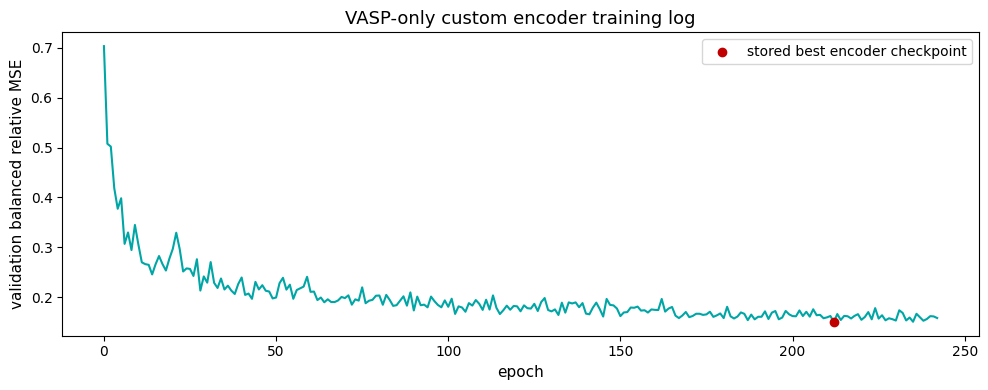

In [15]:
vasp_paper_comparison = pd.DataFrame({
    "dataset": ["Ti_VASP", "Cu_VASP"],
    "paper_ExpertXAS_test_eta": [PAPER_EXPERT_TEST_ETA["Ti_VASP"], PAPER_EXPERT_TEST_ETA["Cu_VASP"]],
    "stored_VASP_only_test_eta": [np.nan, np.nan],
    "stored_test_evaluation": ["not present", "not present"],
    "note": [
        "Ti head checkpoint exists, but no test metrics CSV is stored",
        "Cu feature files exist, but the Cu head directory is absent",
    ],
})
display(vasp_paper_comparison)

vasp_curve = vasp_validation.groupby("epoch", as_index=False)["val_balanced_rel_mse"].min()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(vasp_curve["epoch"], vasp_curve["val_balanced_rel_mse"], color="#00A6A6")
ax.scatter([best_vasp_row["epoch"]], [best_vasp_row["val_balanced_rel_mse"],], color="#C00000", zorder=3, label="stored best encoder checkpoint")
ax.set_xlabel("epoch")
ax.set_ylabel("validation balanced relative MSE")
ax.set_title("VASP-only custom encoder training log")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Cross-folder comparison

The matrix below separates **what is stored** from **what is comparable to the paper**. A missing test score is left missing rather than replaced with a validation score or a paper value.

In [16]:
feff_rows = sum(PAPER_COUNTS[d] for d in DATASET_ORDER if d.endswith("_FEFF"))
vasp_rows = sum(PAPER_COUNTS[d] for d in DATASET_ORDER if d.endswith("_VASP"))

artifact_matrix = pd.DataFrame([
    {
        "folder / run": "cuFeffShellEncoderSweep / run_001",
        "data scope": "Cu FEFF",
        "representation": "learned 384D weighted shells",
        "head/eval artifact": "10-head ExpertXAS ensemble",
        "test eta stored": "yes",
        "paper alignment": "exploratory; not pinned M3GNet",
    },
    {
        "folder / run": "cuFeffShellEncoderSweep / run_002",
        "data scope": "Cu FEFF",
        "representation": "learned 192D weighted shells",
        "head/eval artifact": "10-head ExpertXAS ensemble",
        "test eta stored": "yes",
        "paper alignment": "exploratory; not pinned M3GNet",
    },
    {
        "folder / run": "cuFeffShellEncoderSweep / run_003_two_encoders",
        "data scope": "Cu FEFF",
        "representation": "two learned 192D weighted-shell spaces",
        "head/eval artifact": "20 members and encoder-specific ensembles",
        "test eta stored": "yes",
        "paper alignment": "exploratory; ensemble protocol differs",
    },
    {
        "folder / run": "m3gnetAll8E2EExperts / e2e_expert_seed42",
        "data scope": f"8 FEFF datasets ({feff_rows:,} rows)",
        "representation": "custom scratch end-to-end encoder",
        "head/eval artifact": "joint checkpoint and training log only",
        "test eta stored": "no",
        "paper alignment": "not a paper ExpertXAS test evaluation",
    },
    {
        "folder / run": "m3gnetAll8E2EUniversal / e2e_universal_seed42",
        "data scope": f"8 FEFF + 2 VASP ({PAPER_TOTAL:,} rows)",
        "representation": "custom scratch 64D encoder export",
        "head/eval artifact": "UniversalXAS + tuned eval CSVs",
        "test eta stored": "yes",
        "paper alignment": "directional; encoder/training path differs",
    },
    {
        "folder / run": "vaspOnlyEncoderExperts / vasp_encoder_seed42",
        "data scope": f"2 VASP datasets ({vasp_rows:,} rows)",
        "representation": "custom scratch 64D VASP-only encoder",
        "head/eval artifact": "encoder checkpoint + Ti head; no eval CSV",
        "test eta stored": "no",
        "paper alignment": "incomplete paper-style evaluation",
    },
])
display(artifact_matrix)

,folder / run,data scope,representation,head/eval artifact,test eta stored,paper alignment
0,cuFeffShellEncoderSweep / run_001,Cu FEFF,learned 384D weighted shells,10-head ExpertXAS ensemble,yes,exploratory; not pinned M3GNet
1,cuFeffShellEncoderSweep / run_002,Cu FEFF,learned 192D weighted shells,10-head ExpertXAS ensemble,yes,exploratory; not pinned M3GNet
2,cuFeffShellEncoderSweep / run_003_two_encoders,Cu FEFF,two learned 192D weighted-shell spaces,20 members and encoder-specific ensembles,yes,exploratory; ensemble protocol differs
3,m3gnetAll8E2EExperts / e2e_expert_seed42,"8 FEFF datasets (68,681 rows)",custom scratch end-to-end encoder,joint checkpoint and training log only,no,not a paper ExpertXAS test evaluation
4,m3gnetAll8E2EUniversal / e2e_universal_seed42,"8 FEFF + 2 VASP (75,691 rows)",custom scratch 64D encoder export,UniversalXAS + tuned eval CSVs,yes,directional; encoder/training path differs
5,vaspOnlyEncoderExperts / vasp_encoder_seed42,"2 VASP datasets (7,010 rows)",custom scratch 64D VASP-only encoder,encoder checkpoint + Ti head; no eval CSV,no,incomplete paper-style evaluation


In [17]:
# Compact score view: all stored test eta values that have an explicit paper comparison.
score_view = observed_shell[["run", "combo", "test_eta", "paper_ExpertXAS_test_eta", "paper_UniversalXAS_test_eta", "paper_Tuned_UniversalXAS_test_eta"]].copy()
score_view.insert(0, "source", "Cu shell sweep")
score_view = score_view.rename(columns={"combo": "model_or_combo", "test_eta": "stored_test_eta"})

universal_score_view = universal_comparison[["dataset", "custom_universal_test_eta", "custom_tuned_test_eta", "paper_ExpertXAS_test_eta", "paper_UniversalXAS_test_eta", "paper_Tuned_UniversalXAS_test_eta"]].copy()
universal_score_view.insert(0, "source", "E2E universal")
universal_score_view = universal_score_view.rename(columns={"custom_universal_test_eta": "stored_universal_test_eta", "custom_tuned_test_eta": "stored_tuned_test_eta"})

display(Markdown("**Stored test-score tables**"))
display(score_view.style.format("{:.3f}", subset=pd.IndexSlice[:, ["stored_test_eta", "paper_ExpertXAS_test_eta", "paper_UniversalXAS_test_eta", "paper_Tuned_UniversalXAS_test_eta"]]))
display(universal_score_view.style.format("{:.3f}", subset=pd.IndexSlice[:, ["stored_universal_test_eta", "stored_tuned_test_eta", "paper_ExpertXAS_test_eta", "paper_UniversalXAS_test_eta", "paper_Tuned_UniversalXAS_test_eta"]], na_rep="—"))

**Stored test-score tables**

,source,run,model_or_combo,stored_test_eta,paper_ExpertXAS_test_eta,paper_UniversalXAS_test_eta,paper_Tuned_UniversalXAS_test_eta
2,Cu shell sweep,run_001,learned_site_shells_3_5_weighted_128d,6.769,5.190,2.750,4.810
5,Cu shell sweep,run_002,learned_site_shells_3_5_weighted_64d,7.000,5.190,2.750,4.810
8,Cu shell sweep,run_003_two_encoders,all_20_heads,8.085,5.190,2.750,4.810
9,Cu shell sweep,run_003_two_encoders,encoder_seed43_10_head_ensemble,7.625,5.190,2.750,4.810
10,Cu shell sweep,run_003_two_encoders,best_validation_head,7.196,5.190,2.750,4.810
11,Cu shell sweep,run_003_two_encoders,encoder_seed44_10_head_ensemble,7.049,5.190,2.750,4.810


,source,dataset,stored_universal_test_eta,stored_tuned_test_eta,paper_ExpertXAS_test_eta,paper_UniversalXAS_test_eta,paper_Tuned_UniversalXAS_test_eta
0,E2E universal,Ti_FEFF,10.214,10.606,6.350,4.190,7.630
1,E2E universal,V_FEFF,10.448,11.144,7.300,5.190,9.220
2,E2E universal,Cr_FEFF,15.018,17.372,8.540,7.130,10.440
3,E2E universal,Mn_FEFF,23.228,30.562,17.660,13.150,29.810
4,E2E universal,Fe_FEFF,13.570,14.288,7.510,6.040,8.980
5,E2E universal,Co_FEFF,22.568,25.102,14.470,9.580,19.830
6,E2E universal,Ni_FEFF,15.045,15.278,8.450,6.430,11.210
7,E2E universal,Cu_FEFF,6.141,6.751,5.190,2.750,4.810
8,E2E universal,Ti_VASP,1.032,5.220,4.750,—,5.270
9,E2E universal,Cu_VASP,1.393,7.346,8.460,—,9.210


## 9. Conclusions and reproducibility notes

- The **E2E Universal** folder is the most complete artifact: it contains all ten dataset exports, 64D features, 141D targets, UniversalXAS and tuned-head checkpoints, validation candidates, and selected test evaluations.
- The **Cu shell sweep** contains the richest ensemble comparison. Its scores should be described as learned-encoder experiments, not as exact M3GNet feature-transfer results.
- The **E2E Expert** folder has a useful joint-training checkpoint and validation log, but no exported features or continued per-element test evaluation.
- The **VASP-only Expert** folder has both VASP feature exports and encoder validation logs, but the stored head/evaluation stage is incomplete.
- The CSV checkpoint paths were written on the original training machine and may contain Linux absolute paths. This notebook uses dataset keys, filenames, and local artifact existence rather than trusting those stale absolute paths.
- The run settings consistently record seed 42 for the main experiments and a feature scale of 1000 for the learned shell export. Preserve source checkpoint, representation provenance, preprocessing scale, and split ordering when making future comparisons.

Reference: [OmniXAS: A Universal Deep-Learning Framework for Materials X-ray Absorption Spectra](https://arxiv.org/abs/2409.19552).

In [18]:
# Final lightweight self-checks. These do not open checkpoint weights or run training.
assert set(inventory["folder"]) == set(FOLDER_NAMES)
assert PAPER_TOTAL == 75691
assert universal_shapes["X_dim"].eq(64).all() and universal_shapes["y_dim"].eq(141).all()
assert vasp_shapes["X_dim"].eq(64).all() and vasp_shapes["y_dim"].eq(141).all()
assert universal_shapes["rows_match"].all() and vasp_shapes["rows_match"].all()
assert not universal_comparison.empty
print("Self-check passed: folder inventory, split pairing, dimensions, and paper-scope counts are consistent.")

Self-check passed: folder inventory, split pairing, dimensions, and paper-scope counts are consistent.
